# BTC — TEMA/CMO Robuustheidstest

Twee vragen, niets meer:
1. **Plateau of piek?** Zit (TEMA 100, ATR 3,5) midden in een breed gebied van goede parameters, of is het een geluksvakje omringd door slechte buren?
2. **Generaliseert het?** Tune op 2018-2022, lock de parameters, en kijk wat er gebeurt op 2023-2026.

Realisme: **0,2% fee per kant** en **0,1% slippage op stop-exits** zitten in elke backtest.

Executie-aanname: koop/verkoop op de close van de signaaldag (gelijk aan je eigen notebook, zodat de cijfers vergelijkbaar zijn). Dit is licht optimistisch; next-open zou conservatiever zijn.

Zet `btc_1d.csv` in dezelfde map en draai alles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CSV_PATH    = 'btc_1d.csv'
SPLIT_DATE  = pd.to_datetime('2022-12-31').date()   # IS t/m hier, OOS daarna
BASE_TEMA   = 100      # jouw gekozen parameters
BASE_ATR    = 3.5
BASE_CMO    = 10
FEE         = 0.002    # 0,2% per kant
SLIP        = 0.001    # 0,1% extra verlies op stop-fill
START_CAP   = 1000.0

# ---------- Indicatoren ----------
def tema(series, length):
    e1 = series.ewm(span=length, adjust=False).mean()
    e2 = e1.ewm(span=length, adjust=False).mean()
    e3 = e2.ewm(span=length, adjust=False).mean()
    return 3*(e1 - e2) + e3

def cmo(series, window):
    d  = series.diff()
    up = d.clip(lower=0).rolling(window).sum()
    dn = (-d.clip(upper=0)).rolling(window).sum()
    return 100*(up - dn)/(up + dn)

def atr(df, window=14):
    hl = df['high'] - df['low']
    hc = (df['high'] - df['close'].shift(1)).abs()
    lc = (df['low']  - df['close'].shift(1)).abs()
    tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def prepare(path, tema_len, cmo_win=14, atr_win=14):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    df = df.sort_values('date').reset_index(drop=True)
    # Indicatoren op de VOLLEDIGE reeks (causaal -> geen leakage bij latere slicing)
    df['TEMA'] = tema(df['close'], tema_len)
    df['CMO']  = cmo(df['close'], cmo_win)
    df['ATR']  = atr(df, atr_win)
    return df.dropna().reset_index(drop=True)

print('Indicatoren + data-prep geladen.')

Indicatoren + data-prep geladen.


In [2]:
# ---------- Backtest met fees + slippage ----------
def backtest(df, cmo_trigger=BASE_CMO, atr_mult=BASE_ATR,
             fee=FEE, slip=SLIP, start_capital=START_CAP):
    close = df['close'].values; tm = df['TEMA'].values
    cm = df['CMO'].values;      at = df['ATR'].values
    cash, units = start_capital, 0.0
    in_pos, stop, peak = False, 0.0, 0.0
    entry_eq = None
    equity = np.empty(len(df)); trades = []

    for i in range(len(df)):
        p, t, c, a = close[i], tm[i], cm[i], at[i]
        equity[i] = cash + units*p
        # 1) exit op stop (stop is van vorige dag -> geen lookahead)
        if in_pos and p <= stop:
            fill = p*(1 - slip)
            cash += units*fill*(1 - fee)
            trades.append((entry_eq, cash))
            units, in_pos = 0.0, False
            continue
        # 2) trailing stop bijwerken (voor morgen)
        if in_pos:
            if p > peak: peak = p
            cand = peak - atr_mult*a
            if cand > stop: stop = cand
        # 3) entry
        if (not in_pos) and (p > t) and (c > cmo_trigger):
            entry_eq = cash + units*p
            units = (cash*(1 - fee))/p
            cash = 0.0
            in_pos = True
            peak = p
            stop = p - atr_mult*a

    final = cash + units*close[-1]
    eq = pd.Series(equity)
    rets = eq.pct_change().dropna()
    dd = (eq - eq.cummax())/eq.cummax()
    mdd = dd.min()
    years = len(df)/365.0
    cagr = (final/start_capital)**(1/years) - 1 if (years>0 and final>0) else -1.0
    sharpe  = rets.mean()/rets.std()*np.sqrt(365) if rets.std()>0 else 0.0
    dside   = rets[rets<0].std()
    sortino = rets.mean()/dside*np.sqrt(365) if (dside and dside>0) else 0.0
    calmar  = cagr/abs(mdd) if mdd<0 else 0.0
    wins = sum(1 for e,x in trades if x>e); n = len(trades)
    return dict(final=final, cagr=cagr, sharpe=sharpe, sortino=sortino,
                mdd=mdd, calmar=calmar, trades=n,
                win=(wins/n if n else 0.0), equity=eq, dd=dd, dates=df['date'].values)

def show(name, r):
    print(f"{name:<22} €{r['final']:>11,.0f} | CAGR {r['cagr']*100:6.1f}% | "
          f"Sharpe {r['sharpe']:.2f} | Sortino {r['sortino']:.2f} | "
          f"Calmar {r['calmar']:.2f} | MDD {r['mdd']*100:6.1f}% | "
          f"Trades {r['trades']:>2} | Win {r['win']*100:.0f}%")

print('Backtest-functie geladen.')

Backtest-functie geladen.


## Stap 1 — Baseline-simulatie op (TEMA 100, ATR 3,5)

Eerst je gekozen parameters over de volledige periode, mét frictie, en vergeleken met buy & hold.

=== VOLLEDIGE PERIODE (met fees + slippage) ===
Strategie (100, 3.5)   €     21,499 | CAGR   44.3% | Sharpe 1.02 | Sortino 1.22 | Calmar 0.82 | MDD  -53.8% | Trades 42 | Win 48%
Buy & Hold             €      5,672 | MDD  -76.6%  <- vergelijk hiermee

Strategie verslaat B&H op rendement: True
Strategie heeft lagere drawdown dan B&H: True


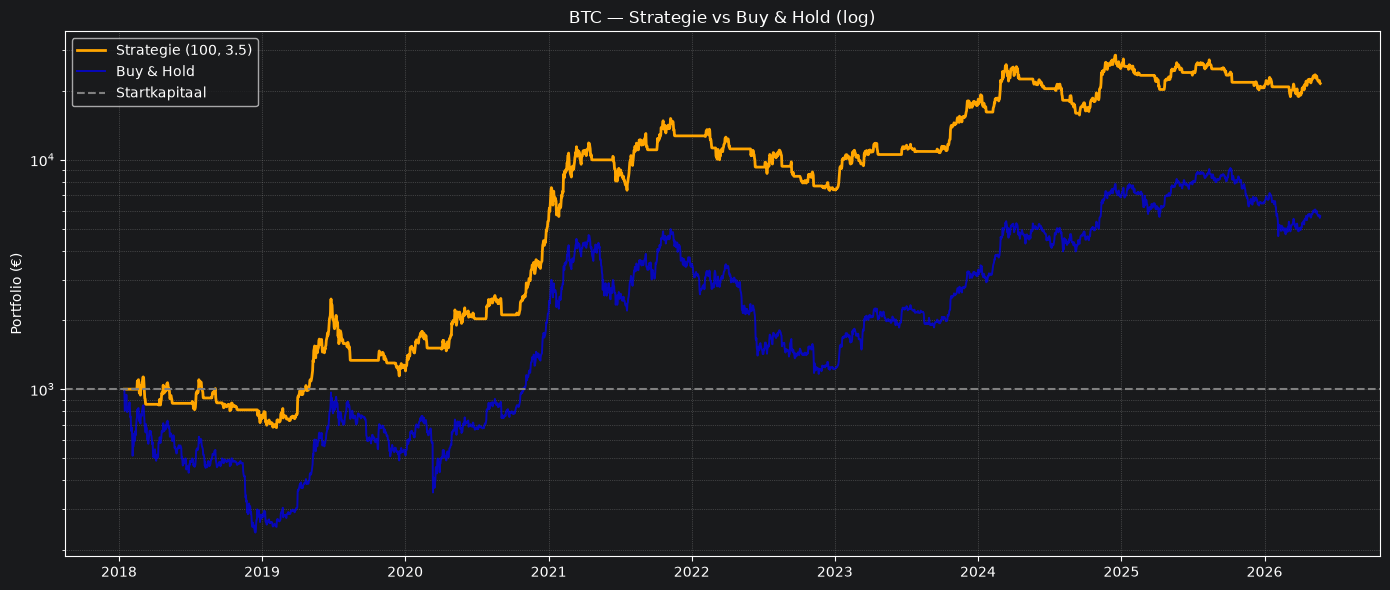

In [3]:
df_full = prepare(CSV_PATH, BASE_TEMA)
base = backtest(df_full, cmo_trigger=BASE_CMO, atr_mult=BASE_ATR)

# Buy & hold benchmark over dezelfde periode
bh_final = START_CAP * df_full['close'].iloc[-1] / df_full['close'].iloc[0]
bh_eq = START_CAP * df_full['close'].values / df_full['close'].iloc[0]
bh_series = pd.Series(bh_eq)
bh_mdd = ((bh_series - bh_series.cummax())/bh_series.cummax()).min()

print('=== VOLLEDIGE PERIODE (met fees + slippage) ===')
show('Strategie (100, 3.5)', base)
print(f"{'Buy & Hold':<22} €{bh_final:>11,.0f} | "
      f"MDD {bh_mdd*100:6.1f}%  <- vergelijk hiermee")
print(f"\nStrategie verslaat B&H op rendement: {base['final'] > bh_final}")
print(f"Strategie heeft lagere drawdown dan B&H: {base['mdd'] > bh_mdd}")

# Equity curve (log)
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(df_full['date'], base['equity'], color='orange', lw=2, label='Strategie (100, 3.5)')
ax.plot(df_full['date'], bh_eq, color='blue', lw=1.4, alpha=0.7, label='Buy & Hold')
ax.axhline(START_CAP, color='gray', ls='--', label='Startkapitaal')
ax.set_yscale('log'); ax.set_title('BTC — Strategie vs Buy & Hold (log)')
ax.set_ylabel('Portfolio (€)'); ax.legend(); ax.grid(True, ls=':', alpha=0.5, which='both')
plt.tight_layout(); plt.show()

## Stap 2 — Heatmap: plateau of piek?

We scannen TEMA-lengte × ATR-multiplier (CMO-trigger vast op 10). Daarna kijken we expliciet of het vakje (100, 3,5) **vergelijkbaar** is met zijn directe buren.

- **Plateau** = (100, 3,5) ligt dicht bij het gemiddelde van zijn buren, buren zijn allemaal fatsoenlijk → robuust.
- **Piek** = (100, 3,5) steekt ver boven zijn buren uit, buren zijn slecht → overfit, niet te vertrouwen.

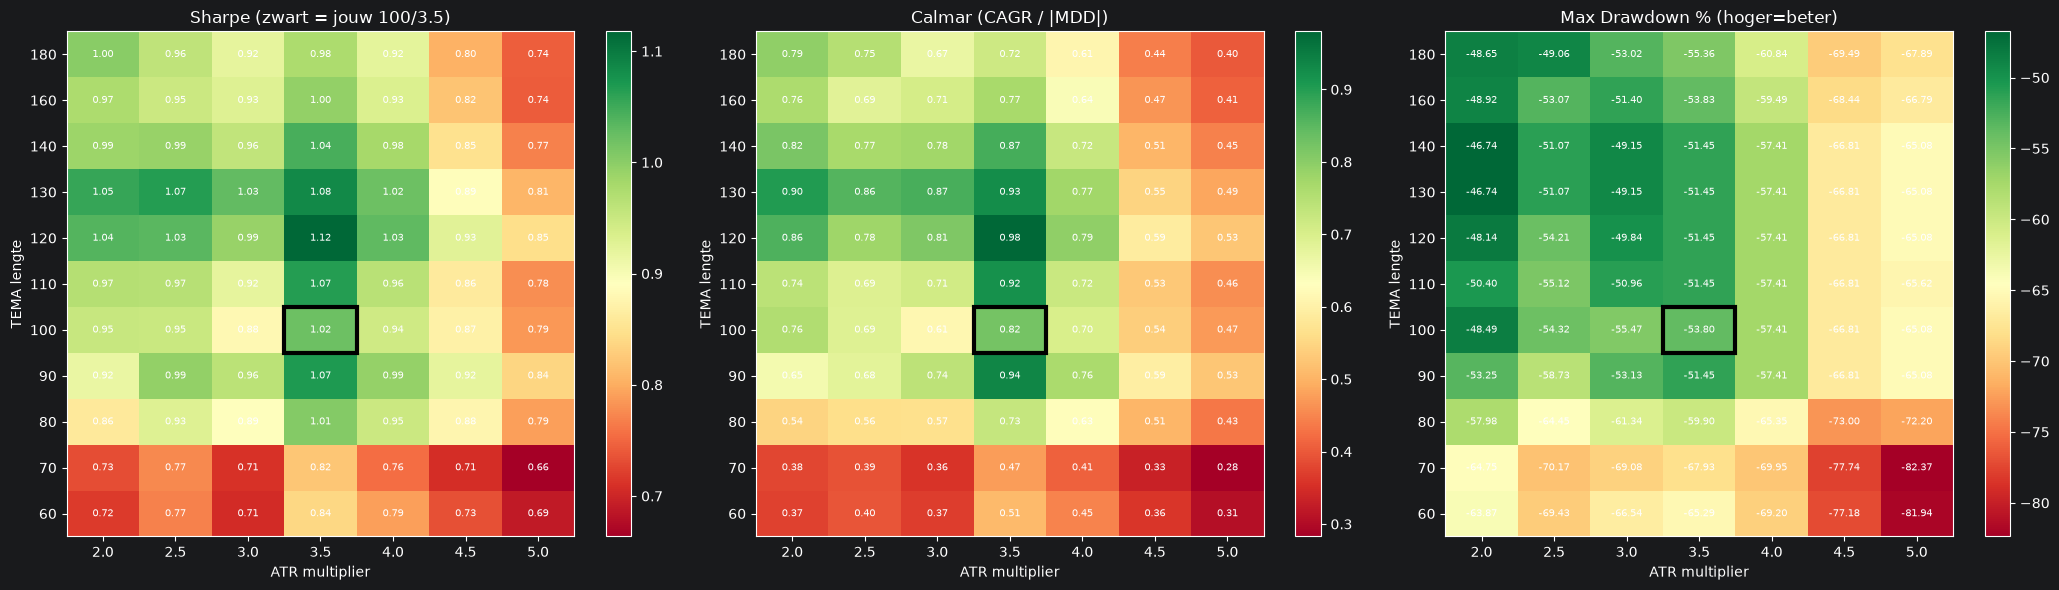

In [4]:
TEMA_GRID = [60, 70, 80, 90, 100, 110, 120, 130, 140, 160, 180]
ATR_GRID  = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

def sweep(path, tema_grid, atr_grid, cmo_trigger=BASE_CMO, date_max=None, date_min=None):
    rows = []
    for tl in tema_grid:
        d = prepare(path, tl)
        if date_min is not None: d = d[d['date'] >= date_min]
        if date_max is not None: d = d[d['date'] <= date_max]
        d = d.reset_index(drop=True)
        if len(d) < 150: continue
        for am in atr_grid:
            r = backtest(d, cmo_trigger=cmo_trigger, atr_mult=am)
            rows.append({'tema':tl, 'atr':am, 'sharpe':r['sharpe'],
                         'calmar':r['calmar'], 'mdd':r['mdd']*100,
                         'cagr':r['cagr']*100, 'trades':r['trades']})
    return pd.DataFrame(rows)

sw = sweep(CSV_PATH, TEMA_GRID, ATR_GRID)

def draw_heatmap(df, metric, ax, title, cmap, highlight=(BASE_TEMA, BASE_ATR)):
    piv = df.pivot(index='tema', columns='atr', values=metric)
    im = ax.imshow(piv.values, aspect='auto', cmap=cmap, origin='lower')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_xlabel('ATR multiplier'); ax.set_ylabel('TEMA lengte'); ax.set_title(title)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f'{piv.values[i,j]:.2f}', ha='center', va='center', fontsize=7.5)
    # markeer jouw gekozen vakje
    if highlight[0] in list(piv.index) and highlight[1] in list(piv.columns):
        yi = list(piv.index).index(highlight[0]); xi = list(piv.columns).index(highlight[1])
        ax.add_patch(patches.Rectangle((xi-0.5, yi-0.5), 1, 1, fill=False,
                                       edgecolor='black', lw=3))
    plt.colorbar(im, ax=ax)
    return piv

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
draw_heatmap(sw, 'sharpe', axes[0], 'Sharpe (zwart = jouw 100/3.5)', 'RdYlGn')
draw_heatmap(sw, 'calmar', axes[1], 'Calmar (CAGR / |MDD|)',          'RdYlGn')
draw_heatmap(sw, 'mdd',    axes[2], 'Max Drawdown % (hoger=beter)',   'RdYlGn')
plt.tight_layout(); plt.show()

In [5]:
# ---------- Kwantitatieve plateau-check ----------
def plateau_check(df, tema, atr, metric='sharpe'):
    piv = df.pivot(index='tema', columns='atr', values=metric)
    if tema not in piv.index or atr not in piv.columns:
        print('Gekozen punt niet in grid.'); return
    ti = list(piv.index).index(tema); ai = list(piv.columns).index(atr)
    chosen = piv.values[ti, ai]
    neigh = []
    for dt in (-1,0,1):
        for da in (-1,0,1):
            if dt==0 and da==0: continue
            nt, na = ti+dt, ai+da
            if 0<=nt<piv.shape[0] and 0<=na<piv.shape[1]:
                neigh.append(piv.values[nt, na])
    neigh = np.array(neigh)
    print(f'--- Plateau-check op metric "{metric}" voor ({tema}, {atr}) ---')
    print(f'Gekozen vakje      : {chosen:.3f}')
    print(f'Buren gemiddelde   : {neigh.mean():.3f}  (std {neigh.std():.3f})')
    print(f'Buren min / max    : {neigh.min():.3f} / {neigh.max():.3f}')
    drop = (chosen - neigh.min())/abs(chosen) if chosen != 0 else float('nan')
    print(f'Slechtste buur ligt {drop*100:.0f}% onder je gekozen vakje')
    if neigh.min() > 0 and chosen <= neigh.mean() + neigh.std():
        print('VERDICT: ziet eruit als PLATEAU (robuust).')
    elif neigh.min() <= 0 or chosen > neigh.mean() + 2*neigh.std():
        print('VERDICT: ziet eruit als PIEK (mogelijk overfit) -> wees voorzichtig.')
    else:
        print('VERDICT: tussenin -> twijfelachtig, leun richtig conservatief.')

plateau_check(sw, BASE_TEMA, BASE_ATR, 'sharpe')
print()
plateau_check(sw, BASE_TEMA, BASE_ATR, 'calmar')

print('\nTop 8 op Calmar (over volledige periode):')
print(sw.sort_values('calmar', ascending=False).head(8).to_string(index=False))

--- Plateau-check op metric "sharpe" voor (100, 3.5) ---
Gekozen vakje      : 1.021
Buren gemiddelde   : 0.975  (std 0.062)
Buren min / max    : 0.881 / 1.069
Slechtste buur ligt 14% onder je gekozen vakje
VERDICT: ziet eruit als PLATEAU (robuust).

--- Plateau-check op metric "calmar" voor (100, 3.5) ---
Gekozen vakje      : 0.824
Buren gemiddelde   : 0.763  (std 0.103)
Buren min / max    : 0.613 / 0.935
Slechtste buur ligt 26% onder je gekozen vakje
VERDICT: ziet eruit als PLATEAU (robuust).

Top 8 op Calmar (over volledige periode):
 tema  atr   sharpe   calmar        mdd      cagr  trades
  120  3.5 1.117822 0.980282 -51.452802 50.438262      40
   90  3.5 1.068795 0.935004 -51.452802 48.108553      42
  130  3.5 1.084791 0.925257 -51.452802 47.607087      40
  110  3.5 1.065009 0.919688 -51.452802 47.320546      41
  130  2.0 1.054448 0.903945 -46.736990 42.247668      64
  140  3.5 1.043726 0.869488 -51.452802 44.737582      40
  130  3.0 1.028741 0.867430 -49.151257 42.635253   

## Stap 3 — Train/test-split (2018-2022 vs 2023-2026)

Twee tests:
- **3a.** Hoe doen *jouw* parameters (100, 3,5) het apart op in-sample vs out-of-sample? Als beide gezond zijn → ze generaliseren.
- **3b.** De strengere test: zoek de beste parameters op 2018-2022, lock ze, en draai ze op 2023-2026. Als de optimale IS-parameters out-of-sample instorten, was de optimalisatie ruis.

In [6]:
# 3a — jouw parameters, IS vs OOS apart
df_is  = df_full[df_full['date'] <= SPLIT_DATE].reset_index(drop=True)
df_oos = df_full[df_full['date'] >  SPLIT_DATE].reset_index(drop=True)

r_is  = backtest(df_is,  cmo_trigger=BASE_CMO, atr_mult=BASE_ATR)
r_oos = backtest(df_oos, cmo_trigger=BASE_CMO, atr_mult=BASE_ATR)

print('=== 3a. JOUW PARAMETERS (100, 3.5) ===')
show('In-sample 2018-2022 ', r_is)
show('Out-sample 2023-2026', r_oos)
for k, lbl in [('sharpe','Sharpe'),('calmar','Calmar')]:
    ratio = r_oos[k]/r_is[k] if r_is[k] not in (0,) else float('nan')
    print(f'  {lbl} OOS/IS-verhouding: {ratio*100:.0f}%  '
          + ('(gezond, >60%)' if (isinstance(ratio,float) and ratio>0.6) else '(zwak, let op)'))

=== 3a. JOUW PARAMETERS (100, 3.5) ===
In-sample 2018-2022    €      7,398 | CAGR   49.6% | Sharpe 1.03 | Sortino 1.22 | Calmar 0.92 | MDD  -53.8% | Trades 25 | Win 44%
Out-sample 2023-2026   €      2,906 | CAGR   36.9% | Sharpe 1.05 | Sortino 1.38 | Calmar 0.93 | MDD  -39.7% | Trades 17 | Win 53%
  Sharpe OOS/IS-verhouding: 102%  (gezond, >60%)
  Calmar OOS/IS-verhouding: 101%  (gezond, >60%)


In [7]:
# 3b — optimaliseer op IS, lock, test op OOS
sw_is = sweep(CSV_PATH, TEMA_GRID, ATR_GRID, date_max=SPLIT_DATE)
best = sw_is.sort_values('calmar', ascending=False).iloc[0]   # optimaliseer op Calmar, niet PnL
bt, ba = int(best['tema']), float(best['atr'])

df_best = prepare(CSV_PATH, bt)
best_oos = backtest(df_best[df_best['date'] > SPLIT_DATE].reset_index(drop=True),
                    cmo_trigger=BASE_CMO, atr_mult=ba)
best_is  = backtest(df_best[df_best['date'] <= SPLIT_DATE].reset_index(drop=True),
                    cmo_trigger=BASE_CMO, atr_mult=ba)

print('=== 3b. BESTE IS-PARAMETERS, GELOCKED, OP OOS ===')
print(f'Beste op 2018-2022 (Calmar): TEMA={bt}, ATR={ba}')
show('Die params op IS    ', best_is)
show('Die params op OOS   ', best_oos)
print()
print(f"Komt de IS-optimale TEMA ({bt}) in de buurt van jouw keuze (100)? "
      f"{'JA' if abs(bt-100)<=20 else 'NEE -> verdacht'}")
print(f"Komt de IS-optimale ATR ({ba}) in de buurt van jouw keuze (3.5)? "
      f"{'JA' if abs(ba-3.5)<=1.0 else 'NEE -> verdacht'}")

=== 3b. BESTE IS-PARAMETERS, GELOCKED, OP OOS ===
Beste op 2018-2022 (Calmar): TEMA=120, ATR=3.5
Die params op IS       €      9,651 | CAGR   57.9% | Sharpe 1.14 | Sortino 1.35 | Calmar 1.12 | MDD  -51.5% | Trades 24 | Win 46%
Die params op OOS      €      3,148 | CAGR   40.2% | Sharpe 1.13 | Sortino 1.48 | Calmar 1.01 | MDD  -39.7% | Trades 16 | Win 56%

Komt de IS-optimale TEMA (120) in de buurt van jouw keuze (100)? JA
Komt de IS-optimale ATR (3.5) in de buurt van jouw keuze (3.5)? JA


## Hoe lees je de uitslag

**Groen licht (waarschijnlijk echt):**
- Heatmap toont een aaneengesloten groen gebied; (100, 3,5) zit er middenin, niet aan de rand.
- Plateau-check zegt PLATEAU op zowel Sharpe als Calmar.
- 3a: OOS-Sharpe ≥ ~60% van IS-Sharpe, en OOS blijft winstgevend.
- 3b: de IS-optimale parameters liggen dicht bij (100, 3,5) én houden stand op OOS.

**Rood licht (overfit / niet vertrouwen):**
- (100, 3,5) is een geïsoleerd groen vakje tussen rode buren.
- Plateau-check zegt PIEK.
- OOS-Sharpe < 50% van IS, of OOS wordt negatief.
- De IS-optimale parameters wijken sterk af van (100, 3,5), of storten in op OOS.

**Als groen:** volgende stappen zijn walk-forward, bootstrap op de trades (95%-interval), en position sizing om de drawdown te temmen — in die volgorde, en pas daarna paper-trading met echte forward-data.